# Case Study - Health Care dataset

In this notebook, we'll explore the possibilties for data privacy on a new dataset.
Your challenge is that you are working with a health care provider, who would like to do the "machine learning" on this dataset to figure out if there are preventative measures that can be taken so fewer patients are seen in the hospital for related care or so that their visits are shorter, to do so you might want to predict the **has_diabetes** according to the features at hand. The goal is that more potentially affected patients are given access to primary care physicians and regular medication or visits that can keep them out of the hostpital for long stays.

## Part One: Determining What's Useful and What's Sensitive

- Data completeness
- Potential sensitive columns
- Potential useful features
- What columns should we use?
- Which ones should we remove?
- Are there columns which we should protect but not remove?

For each, we need some justification or thought!

In [1]:
%matplotlib inline
import pandas as pd
!mkdir data
!wget https://www.lamsade.dauphine.fr/~averine/ProjetIA/data/health_data.csv -P data
df = pd.read_csv('data/health_data.csv')

mkdir: data: File exists
--2025-10-06 20:57:24--  https://www.lamsade.dauphine.fr/~averine/ProjetIA/data/health_data.csv
Resolving www.lamsade.dauphine.fr (www.lamsade.dauphine.fr)... 193.48.71.250
Connecting to www.lamsade.dauphine.fr (www.lamsade.dauphine.fr)|193.48.71.250|:443... connected.
HTTP request sent, awaiting response... --2025-10-06 20:57:24--  https://www.lamsade.dauphine.fr/~averine/ProjetIA/data/health_data.csv
Resolving www.lamsade.dauphine.fr (www.lamsade.dauphine.fr)... 193.48.71.250
Connecting to www.lamsade.dauphine.fr (www.lamsade.dauphine.fr)|193.48.71.250|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 100189 (98K) [text/csv]
Saving to: ‘data/health_data.csv.7’

health_data.csv.7   100%[===================>]  97.84K  --.-KB/s    in 0.02s   

2025-10-06 20:57:24 (5.85 MB/s) - ‘data/health_data.csv.7’ saved [100189/100189]

200 OK
Length: 100189 (98K) [text/csv]
Saving to: ‘data/health_data.csv.7’

health_data.csv.7   100%[===============

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   admitted_ts            1000 non-null   object
 1   age                    1000 non-null   int64 
 2   ambulance_call         1000 non-null   int64 
 3   blood_sugar_reading    1000 non-null   int64 
 4   days_since_last_visit  1000 non-null   int64 
 5   has_diabetes           1000 non-null   int64 
 6   hospital               1000 non-null   object
 7   hours_hospitalized     1000 non-null   int64 
 8   hydration_level        1000 non-null   int64 
 9   id                     1000 non-null   int64 
 10  insulin                1000 non-null   int64 
 11  marital_status         1000 non-null   object
 12  no_primary_dr          1000 non-null   bool  
 13  patient_name           1000 non-null   object
 14  private_insurance      1000 non-null   int64 
 15  released_sameday      

In [3]:
df.head(10)

,admitted_ts,age,ambulance_call,blood_sugar_reading,days_since_last_visit,has_diabetes,hospital,hours_hospitalized,hydration_level,id,insulin,marital_status,no_primary_dr,patient_name,private_insurance,released_sameday,ssn,symptom_code
0,2018-05-09 12:06:28,49,1,108,99,1,district,15,6,1000,1,single,False,Rachel Shelton,0,0,743-97-4081,4
1,2018-05-12 10:02:55,82,1,70,100,1,general,22,1,1001,1,married,False,Barbara Medina,0,0,698-10-2230,3
2,2018-05-13 12:25:17,71,1,100,78,1,northern,1,4,1002,1,no_answer,True,Kaitlyn Daniels,0,1,540-83-4297,2
3,2018-05-14 12:20:08,87,0,113,72,1,general,22,4,1003,1,no_answer,False,William Reyes,1,0,282-96-8755,0
4,2018-05-17 08:35:23,53,1,93,80,1,district,17,8,1004,0,no_answer,True,Eric Booth,0,0,130-25-8918,8
5,2018-05-18 12:13:50,41,0,83,21,1,central,13,8,1005,1,divorced,False,Lisa Hansen,1,0,722-32-7472,6
6,2018-05-21 08:06:34,29,1,116,76,1,district,7,8,1006,0,single,False,Kevin Medina,1,1,875-20-5428,4
7,2018-05-23 09:45:05,84,0,118,44,1,northern,16,5,1007,0,single,True,Julie Daniel,0,0,338-55-1056,1
8,2018-05-26 10:33:57,81,0,109,58,0,district,17,4,1008,1,no_answer,False,Gregory Cooke,1,0,532-35-9220,0
9,2018-05-31 08:44:29,38,1,138,57,1,district,22,8,1009,1,divorced,True,Michael Smith,0,0,427-02-7482,6


## Part Two: Determining the Approach for Protecting the Columns

You are the database manager at the health care provider asked to prepare the data to send to a machine learning consultant who will help give you a more detailed analysis. The consultant has signed all the necessary NDAs, but you have instructions to keep the private or potentially sensitive data to a minimum.

Based on the scenario and what you learned

- What methods will be most effective?
- Have you considered potential data leakage within the *non-sensitive* columns?
- Is there other sensitive or secret data we should address?

**Most effective methods**
- Data minimization: keep only features needed for the task; drop direct identifiers (id, patient_name, ssn) and high-risk codes.
- Generalization/bucketing: bin age (e.g., 10-year bands), coarsen timestamps to day/week/month or part-of-week, simplify rare categories.
- Suppression/aggregation: suppress or aggregate rare groups to meet k-anonymity (e.g., k ≥ 5). Consider l-diversity/t-closeness mindset for sensitive attributes.
- Noise and differential privacy: add calibrated noise to aggregates/EDA; consider DP mechanisms for published statistics or models.

**Data leakage in non-sensitive columns**
- Target leakage: features that occur after or because of the outcome. Likely leaky here: insulin (treatment highly indicative of diabetes), hours_hospitalized, released_sameday. Exclude these if predicting diabetes risk at admission.
- Time leakage: full-precision admitted_ts can re-identify and enable future info to leak if you randomly split; use coarse features (day-of-week, month) and time-aware train/test splits.
- Quasi-identifiers: combinations like age + marital_status + hospital can re-identify; generalize/bucket and group rare combos.

## Part Three: Implement Data Protection for the Dataset

Now it's time to code! Feel free to utilize code from the previous notebooks to implement protection of at least two of the columns you chose as sensitive.

- What was difficult to decide and implement?
- How might this relate to real problems in machine learning with sensitive data?



In [4]:
# Delete unused columns
df.drop(columns=['id', 'patient_name', 'ssn', 'private_insurance', 'symptom_code'], inplace=True)
df

,admitted_ts,age,ambulance_call,blood_sugar_reading,days_since_last_visit,has_diabetes,hospital,hours_hospitalized,hydration_level,insulin,marital_status,no_primary_dr,released_sameday
0,2018-05-09 12:06:28,49,1,108,99,1,district,15,6,1,single,False,0
1,2018-05-12 10:02:55,82,1,70,100,1,general,22,1,1,married,False,0
2,2018-05-13 12:25:17,71,1,100,78,1,northern,1,4,1,no_answer,True,1
3,2018-05-14 12:20:08,87,0,113,72,1,general,22,4,1,no_answer,False,0
4,2018-05-17 08:35:23,53,1,93,80,1,district,17,8,0,no_answer,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2018-09-11 12:14:33,75,0,83,38,0,general,9,9,1,divorced,False,0
996,2018-09-13 10:09:36,73,0,77,39,0,central,14,1,0,no_answer,False,0
997,2018-09-15 11:35:49,29,1,109,63,1,district,2,2,1,married,False,1
998,2018-09-18 08:41:36,23,0,75,37,0,central,19,4,0,single,False,0


In [5]:
import numpy as np
import pandas as pd
from collections import Counter
from typing import List, Tuple, Dict, Optional
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import matplotlib.pyplot as plt
import time

In [6]:
# -----------------------------
# 1) Make a protected working copy and light preprocessing
# -----------------------------

df_prot = df.copy()

# Coarsen timestamp to reduce re-identification risk
if 'admitted_ts' in df_prot.columns:
    df_prot['admitted_ts'] = pd.to_datetime(df_prot['admitted_ts'], errors='coerce')
    df_prot['admitted_dow'] = df_prot['admitted_ts'].dt.dayofweek  # 0..6
    df_prot['admitted_month'] = df_prot['admitted_ts'].dt.month     # 1..12
    # Drop raw timestamp
    df_prot.drop(columns=['admitted_ts'], inplace=True)

# Identify columns
TARGET = 'has_diabetes'
all_cols = [c for c in df_prot.columns]

# Binary-like columns (except target)
binary_like_cols = [
    c for c in all_cols
    if c != TARGET and df_prot[c].dropna().nunique() <= 2
]

# Categorical (non-binary) columns
categorical_nonbinary_cols = []
for c in all_cols:
    if c == TARGET:
        continue
    if c in binary_like_cols:
        continue
    if df_prot[c].dtype == 'object' or c in ['hospital', 'marital_status', 'admitted_dow', 'admitted_month']:
        categorical_nonbinary_cols.append(c)

# Numeric columns to be protected with Laplace (exclude target and binary-like)
numeric_cols = [
    c for c in df_prot.select_dtypes(include=[np.number]).columns
    if c not in binary_like_cols and c != TARGET
]


In [7]:
# -----------------------------
# 2) Differential Privacy mechanisms (Reference2): Laplace + Randomized Response
# -----------------------------

def epsilon_from_pq(p: float, q: float) -> float:
    # As in Reference2: epsilon = -ln(p*q)
    p = float(np.clip(p, 1e-9, 1.0))
    q = float(np.clip(q, 1e-9, 1.0))
    return -np.log(p*q)


def laplace_mechanism(series: pd.Series, epsilon: float, sensitivity: Optional[float] = None) -> pd.Series:
    # Scale = sensitivity / epsilon
    if epsilon is None or epsilon <= 0:
        return series  # no noise
    if sensitivity is None:
        s_min, s_max = series.min(), series.max()
        sensitivity = float(s_max - s_min) if pd.notna(s_max) and pd.notna(s_min) else 1.0
        if sensitivity == 0:
            sensitivity = 1.0
    scale = sensitivity / max(epsilon, 1e-9)
    noise = np.random.laplace(loc=0.0, scale=scale, size=series.shape[0])
    return series.astype(float) + noise


def randomized_response_binary(series: pd.Series, p: float, q: float) -> pd.Series:
    # With prob p, replace with random value: 0 with prob q, 1 with prob (1-q); else keep
    n = series.shape[0]
    base = series.astype(int).copy()
    flip_mask = np.random.rand(n) < np.clip(p, 0.0, 1.0)
    random_vals = (np.random.rand(n) > np.clip(q, 0.0, 1.0)).astype(int)  # 0 with prob q, 1 with prob 1-q
    out = base.copy()
    out[flip_mask] = random_vals[flip_mask]
    return out

In [8]:
# -----------------------------
# 3) k-Anonymity partitioning utilities (adapted from Reference1)
#    We will apply group-level aggregation to each partition to protect both numeric and categorical values.
# -----------------------------

# Build categorical set for the Reference1 helpers (include non-binary categoricals)
_categorical_set = set(categorical_nonbinary_cols)


def _get_spans(df_ref: pd.DataFrame, partition: pd.Index, scale: Optional[Dict[str, float]] = None) -> Dict[str, float]:
    spans = {}
    for column in df_ref.columns:
        s = df_ref[column].loc[partition]
        # Treat booleans like categorical to avoid unsupported numeric subtraction
        is_bool = (s.dtype == bool) or (getattr(s.dtype, 'kind', None) == 'b')
        if column in _categorical_set or is_bool:
            span = s.nunique()
        else:
            try:
                span = s.max() - s.min()
            except TypeError:
                # Fallback for unexpected dtypes
                span = s.nunique()
        if scale is not None and column in scale and scale[column] not in (0, None):
            span = span / scale[column]
        spans[column] = float(span) if span is not None else 0.0
    return spans


def _split(df_ref: pd.DataFrame, partition: pd.Index, column: str) -> Tuple[pd.Index, pd.Index]:
    col = df_ref[column].loc[partition]
    if column in _categorical_set:
        values = col.dropna().unique()
        values = np.array(sorted(values, key=lambda x: str(x)))
        if len(values) <= 1:
            return col.index, col.index  # unsplittable
        lv = set(values[: len(values)//2])
        rv = set(values[len(values)//2 :])
        return col.index[col.isin(lv)], col.index[col.isin(rv)]
    else:
        median = col.median()
        if pd.isna(median):
            return col.index, col.index
        if median == col.min():
            left = col.index[col <= median]
            right = col.index[col > median]
        else:
            left = col.index[col < median]
            right = col.index[col >= median]
        return left, right


def _is_k_anonymous(df_ref: pd.DataFrame, partition: pd.Index, sensitive_column: str, k: int = 5) -> bool:
    return len(partition) >= int(k)


def _partition_dataset(
    df_ref: pd.DataFrame,
    feature_columns: List[str],
    sensitive_column: str,
    scale: Dict[str, float],
    is_valid,
    max_depth: int = 10,
    min_partition_size: Optional[int] = None,
) -> List[pd.Index]:
    final_partitions: List[pd.Index] = []
    # track depth alongside partition
    pending: List[Tuple[pd.Index, int]] = [(df_ref.index, 0)]
    while pending:
        part, depth = pending.pop(0)
        # Early stop: depth or size
        if (max_depth is not None and depth >= max_depth) or \
           (min_partition_size is not None and len(part) < min_partition_size):
            final_partitions.append(part)
            continue
        spans = _get_spans(df_ref[feature_columns], part, scale)
        did_split = False
        for column, _span in sorted(spans.items(), key=lambda x: -x[1]):
            l, r = _split(df_ref, part, column)
            if len(l) == 0 or len(r) == 0:
                continue
            if not is_valid(df_ref, l, sensitive_column) or not is_valid(df_ref, r, sensitive_column):
                continue
            pending.extend([(l, depth + 1), (r, depth + 1)])
            did_split = True
            break
        if not did_split:
            final_partitions.append(part)
    return final_partitions


def _aggregate_partition_values(df_ref: pd.DataFrame, part: pd.Index, num_cols: List[str], cat_cols: List[str]) -> Dict[str, object]:
    agg: Dict[str, object] = {}
    # Numeric -> mean
    for c in num_cols:
        agg[c] = float(df_ref.loc[part, c].mean())
    # Categorical -> mode (most common)
    for c in cat_cols:
        vals = df_ref.loc[part, c]
        if vals.isna().all():
            agg[c] = np.nan
        else:
            most_common = Counter(vals.dropna().tolist()).most_common(1)[0][0]
            agg[c] = most_common
    return agg


def apply_k_anonymity_aggregation(
    df_in: pd.DataFrame,
    feature_columns: List[str],
    sensitive_column: str,
    k: int,
    max_depth: int = 10,
    min_partition_size: Optional[int] = None,
) -> pd.DataFrame:
    if k is None or k <= 1 or not feature_columns:
        return df_in.copy()
    # Build scales on full data for relative spans
    full_spans = _get_spans(df_in[feature_columns], df_in.index, scale=None)
    partitions = _partition_dataset(
        df_in, feature_columns, sensitive_column, full_spans,
        lambda *args: _is_k_anonymous(*args, k=k),
        max_depth=max_depth, min_partition_size=min_partition_size
    )

    df_out = df_in.copy()
    num_cols_local = [c for c in feature_columns if c in df_in.columns and c not in _categorical_set]
    cat_cols_local = [c for c in feature_columns if c in df_in.columns and c in _categorical_set]

    for part in partitions:
        agg = _aggregate_partition_values(df_in, part, num_cols_local, cat_cols_local)
        for c, v in agg.items():
            df_out.loc[part, c] = v
    return df_out

In [9]:
# -----------------------------
# 4) End-to-end protection function combining all techniques
# -----------------------------

def protect_dataset(
    df_base: pd.DataFrame,
    epsilon: Optional[float] = 1.0,
    p: Optional[float] = 0.3,
    q: Optional[float] = 0.5,
    k: Optional[int] = 5,
    max_depth: Optional[int] = None,
    min_partition_size: Optional[int] = None,
) -> pd.DataFrame:
    protected = df_base.copy()

    # Laplace for numeric
    if epsilon is not None:
        for c in numeric_cols:
            protected[c] = laplace_mechanism(protected[c], epsilon=epsilon)

    # Randomized response for binary-like categories
    if p is not None and q is not None:
        for c in binary_like_cols:
            protected[c] = randomized_response_binary(protected[c], p=float(p), q=float(q))

    # k-anonymity aggregation on selected quasi-identifiers (mix numeric/categorical)
    # Slimmed to impactful few as requested
    qi_cols = [c for c in ['age', 'hospital', 'marital_status'] if c in protected.columns and c != TARGET]

    # Mark non-binary categoricals into the helper set dynamically
    global _categorical_set
    _categorical_set = set([c for c in categorical_nonbinary_cols if c in qi_cols])

    protected = apply_k_anonymity_aggregation(
        protected, qi_cols, sensitive_column=TARGET, k=int(k) if k else 5,
        max_depth=max_depth, min_partition_size=min_partition_size
    )
    return protected

In [10]:
# -----------------------------
# 5) Modeling helpers and tradeoff evaluation
# -----------------------------

def build_model_pipeline(df_in: pd.DataFrame, estimator: Optional[object] = None) -> Tuple[Pipeline, List[str], List[str]]:
    X = df_in.drop(columns=[TARGET])
    y = df_in[TARGET].astype(int)

    # Recompute types for this df
    num_cols_local = [c for c in X.select_dtypes(include=[np.number]).columns]
    # Treat these as categorical regardless of numeric dtype (derived time parts)
    cat_force = [c for c in ['admitted_dow', 'admitted_month'] if c in X.columns]
    # Non-binary categoricals
    cat_cols_local = list(set([c for c in X.columns if (X[c].dtype == 'object') or (c in cat_force)]) )
    # Remove overlap
    num_cols_local = [c for c in num_cols_local if c not in cat_cols_local]

    # OneHotEncoder compatibility across sklearn versions
    try:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

    preproc = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(with_mean=False), num_cols_local),
            ('cat', ohe, cat_cols_local),
        ],
        remainder='drop'
    )
    if estimator is None:
        estimator = LogisticRegression(max_iter=500, solver='lbfgs')
    pipe = Pipeline([
        ('prep', preproc),
        ('clf', estimator)
    ])
    return pipe, num_cols_local, cat_cols_local


def evaluate_df_pre_split(
    Xtr: pd.DataFrame, Xte: pd.DataFrame, ytr: pd.Series, yte: pd.Series, estimator: Optional[object] = None
) -> Tuple[float, float]:
    df_train = pd.concat([Xtr, ytr.rename(TARGET)], axis=1)
    pipe, _, _ = build_model_pipeline(df_train, estimator=estimator)
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    acc = accuracy_score(yte, pred)
    rec = recall_score(yte, pred)
    return acc, rec


def get_presplit(df_in: pd.DataFrame, test_size: float = 0.25, seed: int = 0):
    X = df_in.drop(columns=[TARGET])
    y = df_in[TARGET].astype(int)
    return train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)

# Baseline (non-protected) metrics for reference using pre-split
try:
    Xtr0, Xte0, ytr0, yte0 = get_presplit(df_prot, test_size=0.25, seed=0)
    baseline_acc, baseline_rec = evaluate_df_pre_split(Xtr0, Xte0, ytr0, yte0)
except Exception:
    baseline_acc, baseline_rec = (np.nan, np.nan)

print(f"Baseline (no protection) - Accuracy: {baseline_acc:.3f}, Recall: {baseline_rec:.3f}")

Baseline (no protection) - Accuracy: 0.752, Recall: 0.995


[sweep] epsilon sweep start | epsilons=[0.2, 0.5, 1.0, 2.0, 5.0]
[sweep] epsilon sweep done in 5.27s
[sweep] p sweep start | p_list=[0.1, 0.2, 0.3, 0.5, 0.7], q=0.5
[sweep] epsilon sweep done in 5.27s
[sweep] p sweep start | p_list=[0.1, 0.2, 0.3, 0.5, 0.7], q=0.5


/var/folders/tp/j_rkz46n6z519dkc3t08mt500000gn/T/ipykernel_1390/4278000577.py:133: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18.8' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_out.loc[part, c] = v
/var/folders/tp/j_rkz46n6z519dkc3t08mt500000gn/T/ipykernel_1390/4278000577.py:133: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18.8' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_out.loc[part, c] = v
/var/folders/tp/j_rkz46n6z519dkc3t08mt500000gn/T/ipykernel_1390/4278000577.py:133: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18.8' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_out.loc[part, c] = v
/var/fo

[sweep] p sweep done in 2.24s
[sweep] k sweep start | k_list=[2, 3, 5, 8, 10]


/var/folders/tp/j_rkz46n6z519dkc3t08mt500000gn/T/ipykernel_1390/4278000577.py:133: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18.8' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_out.loc[part, c] = v
/var/folders/tp/j_rkz46n6z519dkc3t08mt500000gn/T/ipykernel_1390/4278000577.py:133: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18.8' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_out.loc[part, c] = v
/var/folders/tp/j_rkz46n6z519dkc3t08mt500000gn/T/ipykernel_1390/4278000577.py:133: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18.8' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_out.loc[part, c] = v
/var/fo

[sweep] k sweep done in 2.17s


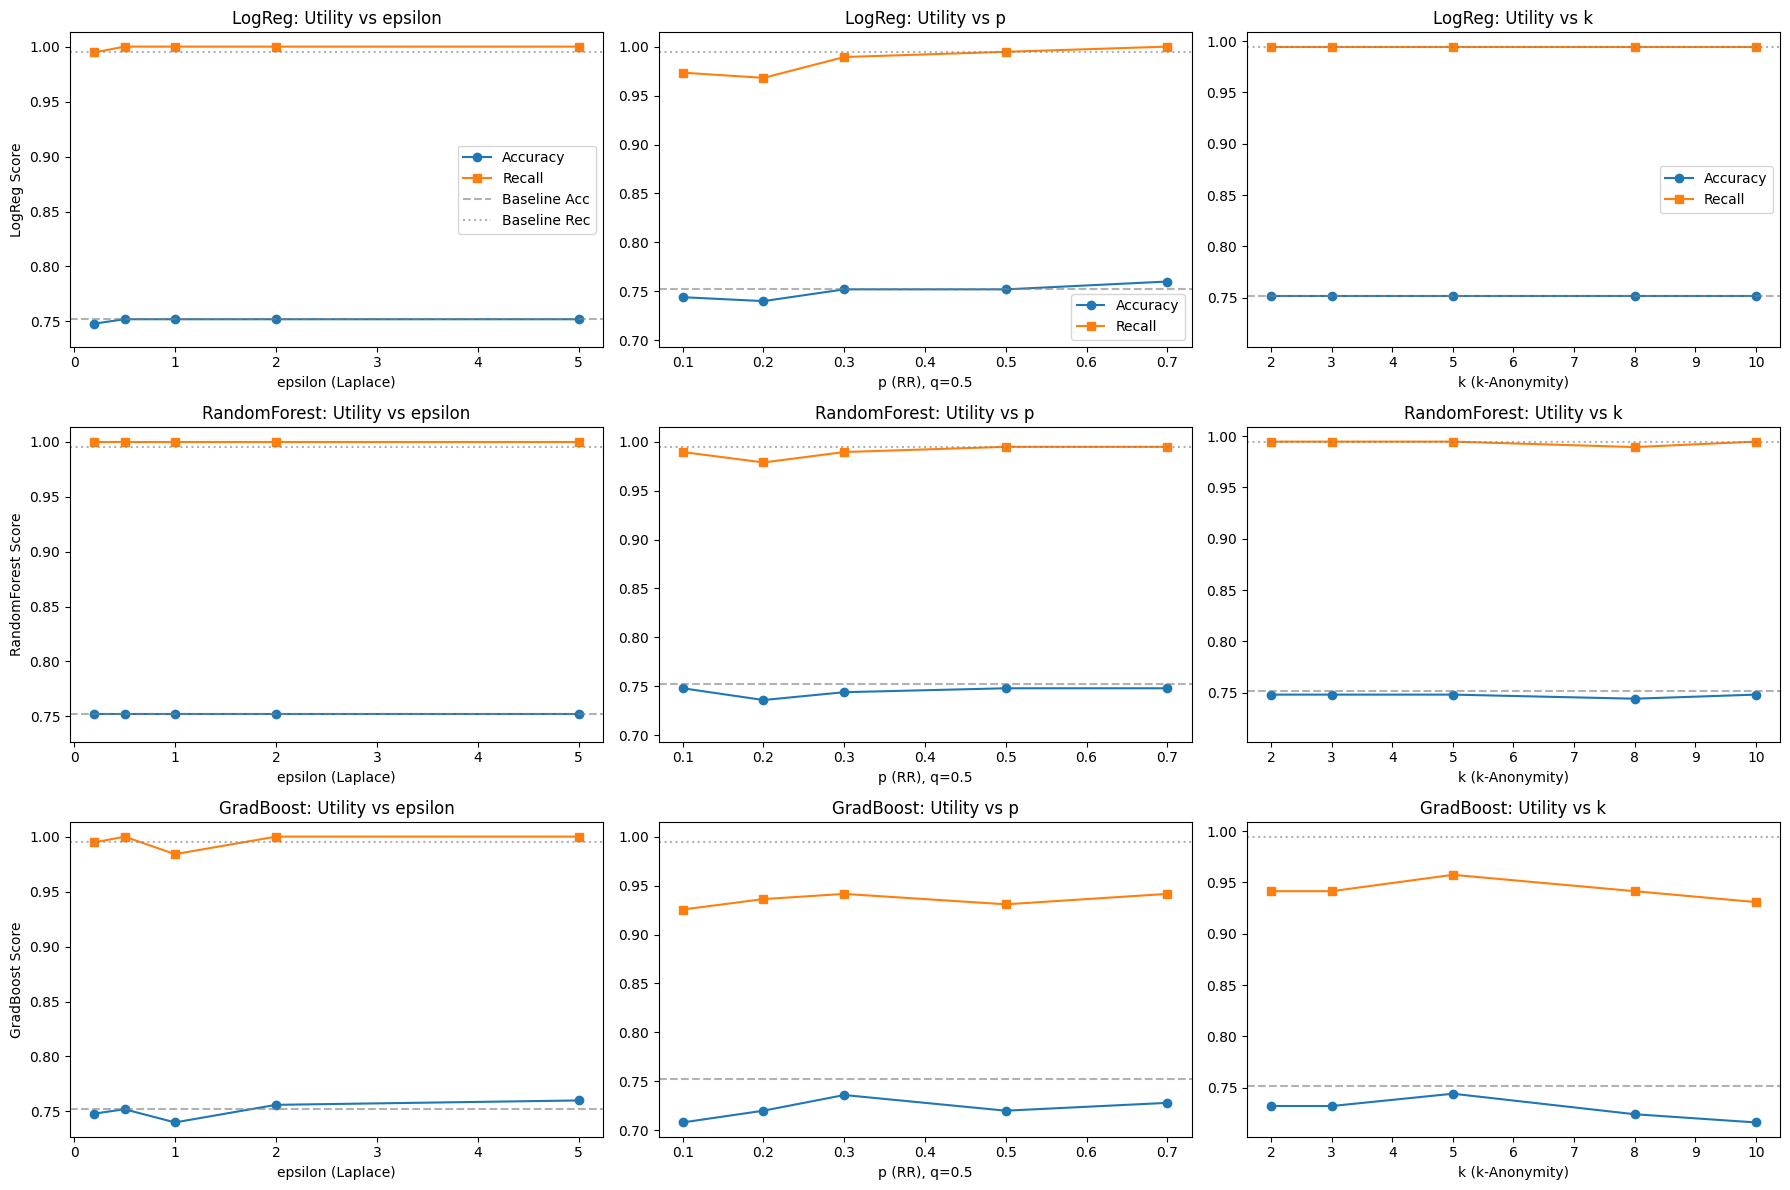

In [11]:
# -----------------------------
# 6) Parameter sweeps and visualization
# -----------------------------

def sweep_and_plot(
    epsilons: List[float], k_list: List[int], p_list: List[float], q: float = 0.5, seed: int = 0
):
    # Pre-split once and reuse
    Xtr, Xte, ytr, yte = get_presplit(df_prot, test_size=0.25, seed=seed)

    # Define model zoo
    models = {
        'LogReg': LogisticRegression(max_iter=500, solver='lbfgs'),
        'RandomForest': RandomForestClassifier(n_estimators=250, random_state=seed, n_jobs=-1),
        'GradBoost': GradientBoostingClassifier(random_state=seed)
    }

    # Storage: {param_name: {model: [scores...]}}
    acc_eps = {m: [] for m in models}
    rec_eps = {m: [] for m in models}
    acc_p = {m: [] for m in models}
    rec_p = {m: [] for m in models}
    acc_k = {m: [] for m in models}
    rec_k = {m: [] for m in models}

    # Sweep epsilon (Laplace), fix k=None and p=None for isolation
    t0 = time.time()
    print(f"[sweep] epsilon sweep start | epsilons={epsilons}")
    for eps in epsilons:
        df_eps = protect_dataset(df_prot, epsilon=eps, p=None, q=None, k=None, max_depth=8, min_partition_size=None)
        Xtr_eps = df_eps.drop(columns=[TARGET]).loc[Xtr.index]
        Xte_eps = df_eps.drop(columns=[TARGET]).loc[Xte.index]
        for name, est in models.items():
            a, r = evaluate_df_pre_split(Xtr_eps, Xte_eps, ytr, yte, estimator=est)
            acc_eps[name].append(a)
            rec_eps[name].append(r)
    print(f"[sweep] epsilon sweep done in {time.time()-t0:.2f}s")

    # Sweep p (Randomized Response), fix epsilon=None and k=None
    t1 = time.time()
    print(f"[sweep] p sweep start | p_list={p_list}, q={q}")
    for p_val in p_list:
        df_p = protect_dataset(df_prot, epsilon=None, p=p_val, q=q, k=None, max_depth=8, min_partition_size=None)
        Xtr_p = df_p.drop(columns=[TARGET]).loc[Xtr.index]
        Xte_p = df_p.drop(columns=[TARGET]).loc[Xte.index]
        for name, est in models.items():
            a, r = evaluate_df_pre_split(Xtr_p, Xte_p, ytr, yte, estimator=est)
            acc_p[name].append(a)
            rec_p[name].append(r)
    print(f"[sweep] p sweep done in {time.time()-t1:.2f}s")

    # Sweep k (k-Anonymity), fix epsilon=None and p=None
    t2 = time.time()
    print(f"[sweep] k sweep start | k_list={k_list}")
    for k_val in k_list:
        df_k = protect_dataset(df_prot, epsilon=None, p=None, q=None, k=k_val, max_depth=8, min_partition_size=None)
        Xtr_k = df_k.drop(columns=[TARGET]).loc[Xtr.index]
        Xte_k = df_k.drop(columns=[TARGET]).loc[Xte.index]
        for name, est in models.items():
            a, r = evaluate_df_pre_split(Xtr_k, Xte_k, ytr, yte, estimator=est)
            acc_k[name].append(a)
            rec_k[name].append(r)
    print(f"[sweep] k sweep done in {time.time()-t2:.2f}s")

    # Plot results (3x3 grid: rows = models, cols = params)
    fig, axes = plt.subplots(len(models), 3, figsize=(18, 12), sharey='col')
    model_names = list(models.keys())

    for i, name in enumerate(model_names):
        # epsilon
        ax = axes[i, 0] if len(model_names) > 1 else axes[0]
        ax.plot(epsilons, acc_eps[name], marker='o', label='Accuracy')
        ax.plot(epsilons, rec_eps[name], marker='s', label='Recall')
        ax.axhline(y=baseline_acc, color='gray', linestyle='--', alpha=0.6, label='Baseline Acc' if i == 0 else None)
        ax.axhline(y=baseline_rec, color='gray', linestyle=':', alpha=0.6, label='Baseline Rec' if i == 0 else None)
        ax.set_xlabel('epsilon (Laplace)')
        ax.set_ylabel(f'{name} Score')
        ax.set_title(f'{name}: Utility vs epsilon')
        if i == 0:
            ax.legend()

        # p
        ax = axes[i, 1]
        ax.plot(p_list, acc_p[name], marker='o', label='Accuracy')
        ax.plot(p_list, rec_p[name], marker='s', label='Recall')
        ax.axhline(y=baseline_acc, color='gray', linestyle='--', alpha=0.6)
        ax.axhline(y=baseline_rec, color='gray', linestyle=':', alpha=0.6)
        ax.set_xlabel(f'p (RR), q={q}')
        ax.set_title(f'{name}: Utility vs p')
        if i == 0:
            ax.legend()

        # k
        ax = axes[i, 2]
        ax.plot(k_list, acc_k[name], marker='o', label='Accuracy')
        ax.plot(k_list, rec_k[name], marker='s', label='Recall')
        ax.axhline(y=baseline_acc, color='gray', linestyle='--', alpha=0.6)
        ax.axhline(y=baseline_rec, color='gray', linestyle=':', alpha=0.6)
        ax.set_xlabel('k (k-Anonymity)')
        ax.set_title(f'{name}: Utility vs k')
        if i == 0:
            ax.legend()

    plt.tight_layout()
    plt.show()


# Example sweeps (feel free to adjust ranges)
epsilon_grid = [0.2, 0.5, 1.0, 2.0, 5.0]
k_grid = [2, 3, 5, 8, 10]
p_grid = [0.1, 0.2, 0.3, 0.5, 0.7]

sweep_and_plot(epsilons=epsilon_grid, k_list=k_grid, p_list=p_grid, q=0.5, seed=0)

## Bonus: machine learning from anonymized Dataset

Build a model that predicts the the diabetes statue of a new patient based on the anonymized database from part three. Compare with non anonymized dataset. (try to get more than 0.65 accuracy)

In [12]:

def evaluate_models(Xtr, ytr, Xte, yte):
    models = {
        "LogReg": LogisticRegression(max_iter=1000),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=0),
        "GradBoost": GradientBoostingClassifier(random_state=0),
    }
    out = {}
    for name, model in models.items():
        model.fit(Xtr, ytr)
        pred = model.predict(Xte)
        out[name] = accuracy_score(yte, pred)
    return out